# Generate data from the multiple regression model
- We will be creating a dataset from the multiple regression model using the function `make_regression` from the library ***sklearn.datasets***.
- Assign to the number of samples, features, as well as the standard deviation of the noise and bias values.
- Hyperparameters for genereating data points:
    - `n_train`: integer. The number of the training samples.
    - `n_val`: integer. The number of the validation samples.
    - `n_test`: integer. The number of the test samples.
    - **n_samples**: integer. The number of whole dataset combined. **n_samples** = `n_train` + `n_val` + `n_test`.
    - `n_features`: integer. The number of features of the multiple regression model which we are generate datapoints from.
    - `sd_noise`: tuple. The standard deviation of the gaussian noise applied to the output.
    - `bias_val`: tuple. The bias term in the underlying linear model.
    - `random_state_val`: integer. RNG seed number used in dataset creation.
- A typical split ratio of the datasets might be $\text{Training} : \text{Validation} : \text{Test} = 70 : 15 : 15$ or $60 : 20 : 20$.
- Also, the generated data has been scaled: X_data ranges from $-\pi$ to $\pi$, suitable for applying to rotation angles, and Y_data spans from $-1$ to $1$, applicable for representing $\langle Z \rangle$, respectively.

### Create output folder

In [1]:
import os

dataset_dir = 'dataset_wo_error/'    # dataset_mr_wo_error, dataset_mr_w_error
dataset_EDA_dir = dataset_dir+'EDA_result/'

# Create the folder if it doesn't exist
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

if not os.path.exists(dataset_EDA_dir):
    os.makedirs(dataset_EDA_dir)

# Set save folder directory
print('dataset_dir:', dataset_dir)
print('dataset_EDA_dir:', dataset_EDA_dir)

dataset_dir: dataset_wo_error/
dataset_EDA_dir: dataset_wo_error/EDA_result/


### Generate dataset

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler

In [3]:
def n_sample_calc(number, r_train, r_val, r_test):
    n_train = round(number * r_train)
    n_val = round(number * r_val)
    n_test = round(number * r_test)
    n_samples = n_train + n_val + n_test
    print('---Calculation of the number of samples of each dataset---')
    print('n_train:', n_train)
    print('n_train:', n_val)
    print('n_train:', n_test)
    print('n_samples:', n_samples)

In [4]:
# n_train, n_val, n_test = ratio_func(200, 0.6, 0.2, 0.2)
n_sample_calc(140, 0.7, 0.15, 0.15)

---Calculation of the number of samples of each dataset---
n_train: 98
n_train: 21
n_train: 21
n_samples: 140


In [5]:
# Assign the number of samples and features
n_train = 100
n_val = 20
n_test = 20
n_samples = n_train + n_val + n_test

print('---Assigned number of samples for each dataset---')
print('n_train:', n_train)
print('n_val:', n_val)
print('n_test:', n_test)
print('n_samples:', n_samples, '\n')

n_features = 4
n_informative = 4

if dataset_dir == 'dataset_wo_error/':
    noise_sd = 0.0
    bias_val = 0.0
elif dataset_dir == 'dataset_w_error/':
    noise_sd = 0.01
    bias_val = 0.0

random_state_val = 42

print('---Parameters of the function `make_regression`---')
print('n_features:', n_features)
print('sd_noise:', noise_sd)
print('bias_val:', bias_val)
print('random_state_val:', random_state_val)

---Assigned number of samples for each dataset---
n_train: 100
n_val: 20
n_test: 20
n_samples: 140 

---Parameters of the function `make_regression`---
n_features: 4
sd_noise: 0.0
bias_val: 0.0
random_state_val: 42


In [6]:
# Generate X from a uniform distribution
X = np.random.uniform(low=0, high=np.pi, size=(n_samples, n_features))

# Generate random weights for the linear model
weights = np.random.randn(n_features)  # Normally distributed weights
bias = np.random.randn()  # Random bias term

# Compute y = Xw + bias + noise, adding noise
noise = np.random.normal(loc=0, scale=noise_sd, size=n_samples)
y = X @ weights + bias + noise

print("Generated weights:", weights)
print("Bias:", bias)
print("Feature matrix X (first 5 rows):\n", X[:5])
print("Target values y (first 5):", y[:5])

Generated weights: [-0.68554838  1.53459318 -0.5508043   0.75810025]
Bias: 0.26579123628912027
Feature matrix X (first 5 rows):
 [[1.03093586 0.46421642 1.63574923 2.14678393]
 [1.32839834 0.3185596  0.09140979 0.53166161]
 [1.60540795 0.52470906 1.13285378 1.5560807 ]
 [1.93151897 2.69937556 2.97796481 1.01379146]
 [1.93735006 2.34005092 0.57953111 0.83724572]]
Target values y (first 5): [0.99791791 0.19667319 0.52610579 2.21236459 2.84417819]


In [7]:
# Desired ranges for X and Y
X_min, X_max = 0, np.pi
y_min, y_max = -1, 1

# Scale the features to a given range: (0, np.pi)
feature_scaler = MinMaxScaler(feature_range=(X_min, X_max))
X_scaled = feature_scaler.fit_transform(X)

# Scale the target to a given range: [-1, 1]
y_min, y_max = -1, 1
y_scaled = y_min + (y - np.min(y)) * (y_max - y_min) / (np.max(y) - np.min(y))

# Calculate Y using the linear relationship with the original coefficient
y_rescaled = X_scaled.dot(weights) + noise

# Rescale Y to the desired range
y_min_actual, y_max_actual = y_rescaled.min(), y_rescaled.max()
y_scaled = y_min + (y_rescaled - y_min_actual) * (y_max - y_min) / (y_max_actual - y_min_actual)

# Generate column names based on the shape of the array
num_rows, num_cols = X_scaled.shape
column_names = [f'feature{i+1}' for i in range(num_cols)]

# Create a DataFrame with the generated column names
data = pd.DataFrame(X_scaled, columns=column_names)
data['target'] = y_scaled

print('Data head:\n', data.head(), '\n')
print('Data description:\n', data.describe(), '\n')
print('reg_coef:', weights)

Data head:
    feature1  feature2  feature3  feature4    target
0  1.028572  0.450394  1.651965  2.141351 -0.275683
1  1.331453  0.303780  0.082344  0.516459 -0.491243
2  1.613508  0.511285  1.140837  1.547075 -0.404104
3  1.945559  2.700251  3.016153  1.001505  0.049972
4  1.951496  2.338563  0.578456  0.823891  0.224846 

Data description:
          feature1    feature2    feature3    feature4      target
count  140.000000  140.000000  140.000000  140.000000  140.000000
mean     1.615630    1.604974    1.508184    1.545448   -0.007067
std      0.907415    0.873882    0.923322    0.935276    0.452266
min      0.000000    0.000000    0.000000    0.000000   -1.000000
25%      0.815966    0.858282    0.745903    0.701464   -0.311005
50%      1.676695    1.593376    1.426932    1.708294   -0.044421
75%      2.317717    2.346273    2.335678    2.263798    0.286191
max      3.141593    3.141593    3.141593    3.141593    1.000000 

reg_coef: [-0.68554838  1.53459318 -0.5508043   0.75810025]

In [8]:
# # Generate a synthetic regression dataset
# X, y, reg_coef = make_regression(
#     n_samples=n_samples,                # num. of samples
#     n_features=n_features,              # num. of features
#     n_informative=n_informative,           # The number of informative features which is used to generate the output.
#     n_targets=1,                        # The number of regression targets
#     noise=noise_sd,                     # The standard deviation of the gaussian noise applied to the output
#     bias=bias_val,                      # The bias term
#     coef=True,                          # If True, the coefficients of the underlying linear model are returned.
#     shuffle=False,                      # Shuffle the samples and the features.
#     random_state=random_state_val       # Determines random number generation for dataset creation.
#     )

# # Desired ranges for X and Y
# X_min, X_max = 0, np.pi
# y_min, y_max = -1, 1

# # Scale the features to a given range: (0, np.pi)
# feature_scaler = MinMaxScaler(feature_range=(X_min, X_max))
# X_scaled = feature_scaler.fit_transform(X)

# # Scale the target to a given range: [-1, 1]
# y_min, y_max = -1, 1
# y_scaled = y_min + (y - np.min(y)) * (y_max - y_min) / (np.max(y) - np.min(y))

# # Calculate Y using the linear relationship with the original coefficient
# y_rescaled = X_scaled.dot(reg_coef) + bias_val

# # Rescale Y to the desired range
# y_min_actual, y_max_actual = y_rescaled.min(), y_rescaled.max()
# y_scaled = y_min + (y_rescaled - y_min_actual) * (y_max - y_min) / (y_max_actual - y_min_actual)

# # Generate column names based on the shape of the array
# num_rows, num_cols = X_scaled.shape
# column_names = [f'feature{i+1}' for i in range(num_cols)]

# # Create a DataFrame with the generated column names
# data = pd.DataFrame(X_scaled, columns=column_names)
# data['target'] = y_scaled

# print('Data head:\n', data.head(), '\n')
# print('Data description:\n', data.describe(), '\n')
# print('reg_coef:', reg_coef)

# Split the dataset into training, validation, and test sets.
- We will be splitting the data into training, validation, and test datasets, with specified numbers of data points for each.

In [9]:
from sklearn.model_selection import train_test_split

# Split data into training + validation and test sets
data_train_val, data_test = train_test_split(data, test_size=n_test, random_state=random_state_val)

# Now split the training + validation set into separate training and validation sets
data_train, data_val = train_test_split(data_train_val, test_size=n_val, random_state=random_state_val)

print('---Shape of each datasets---')
print("Training set shape:", data_train.shape)
print("Validation set shape:", data_val.shape)
print("Test set shape:", data_test.shape)

---Shape of each datasets---
Training set shape: (100, 5)
Validation set shape: (20, 5)
Test set shape: (20, 5)


# Exploratory Data Analysis (EDA) on the generated dataset

## Scatter plot of the dataset

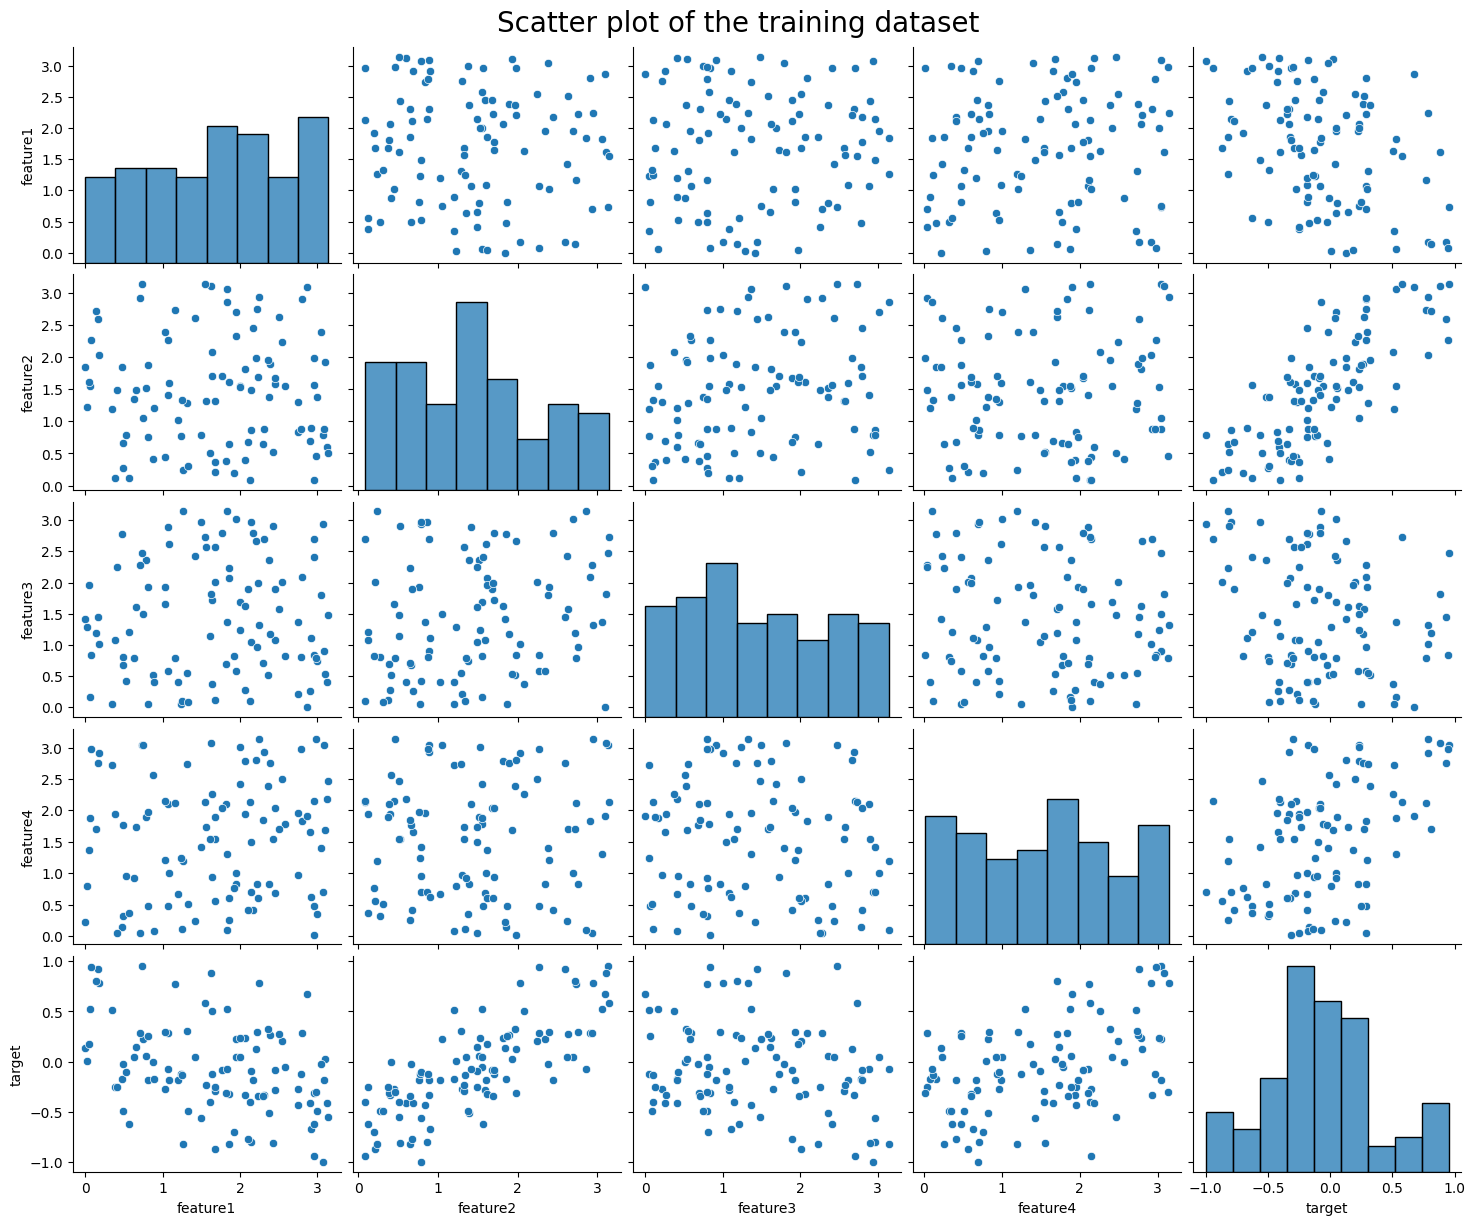

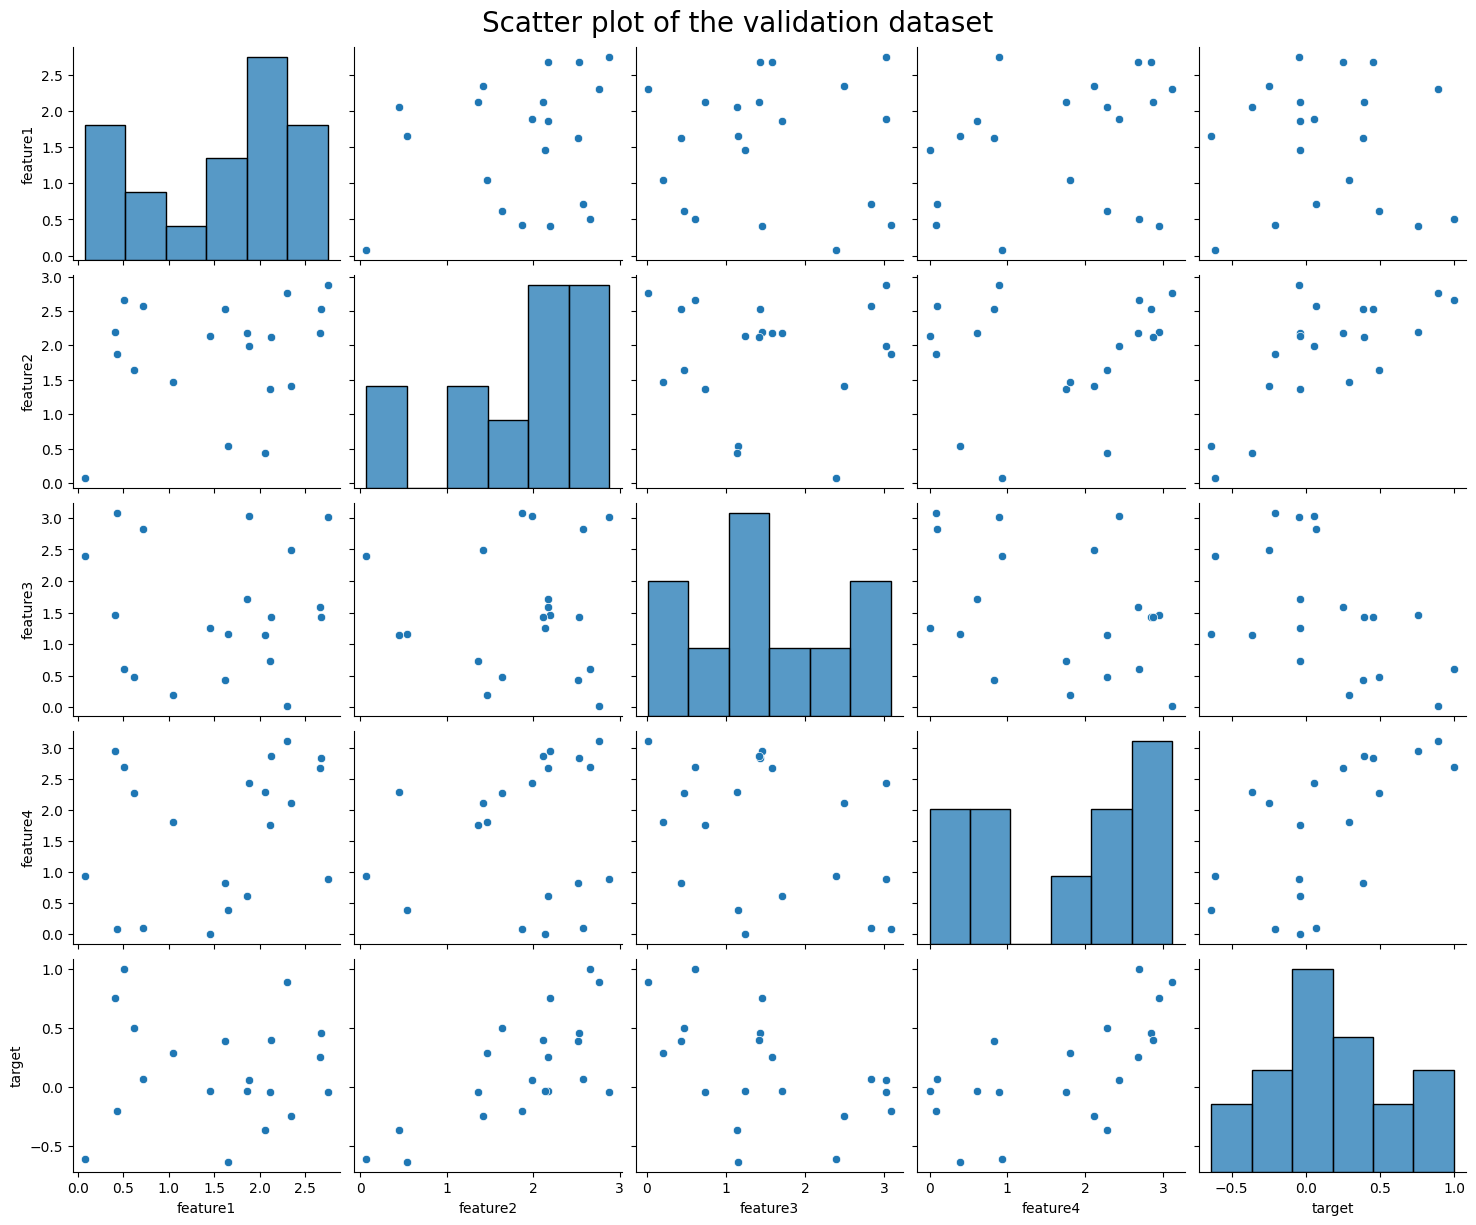

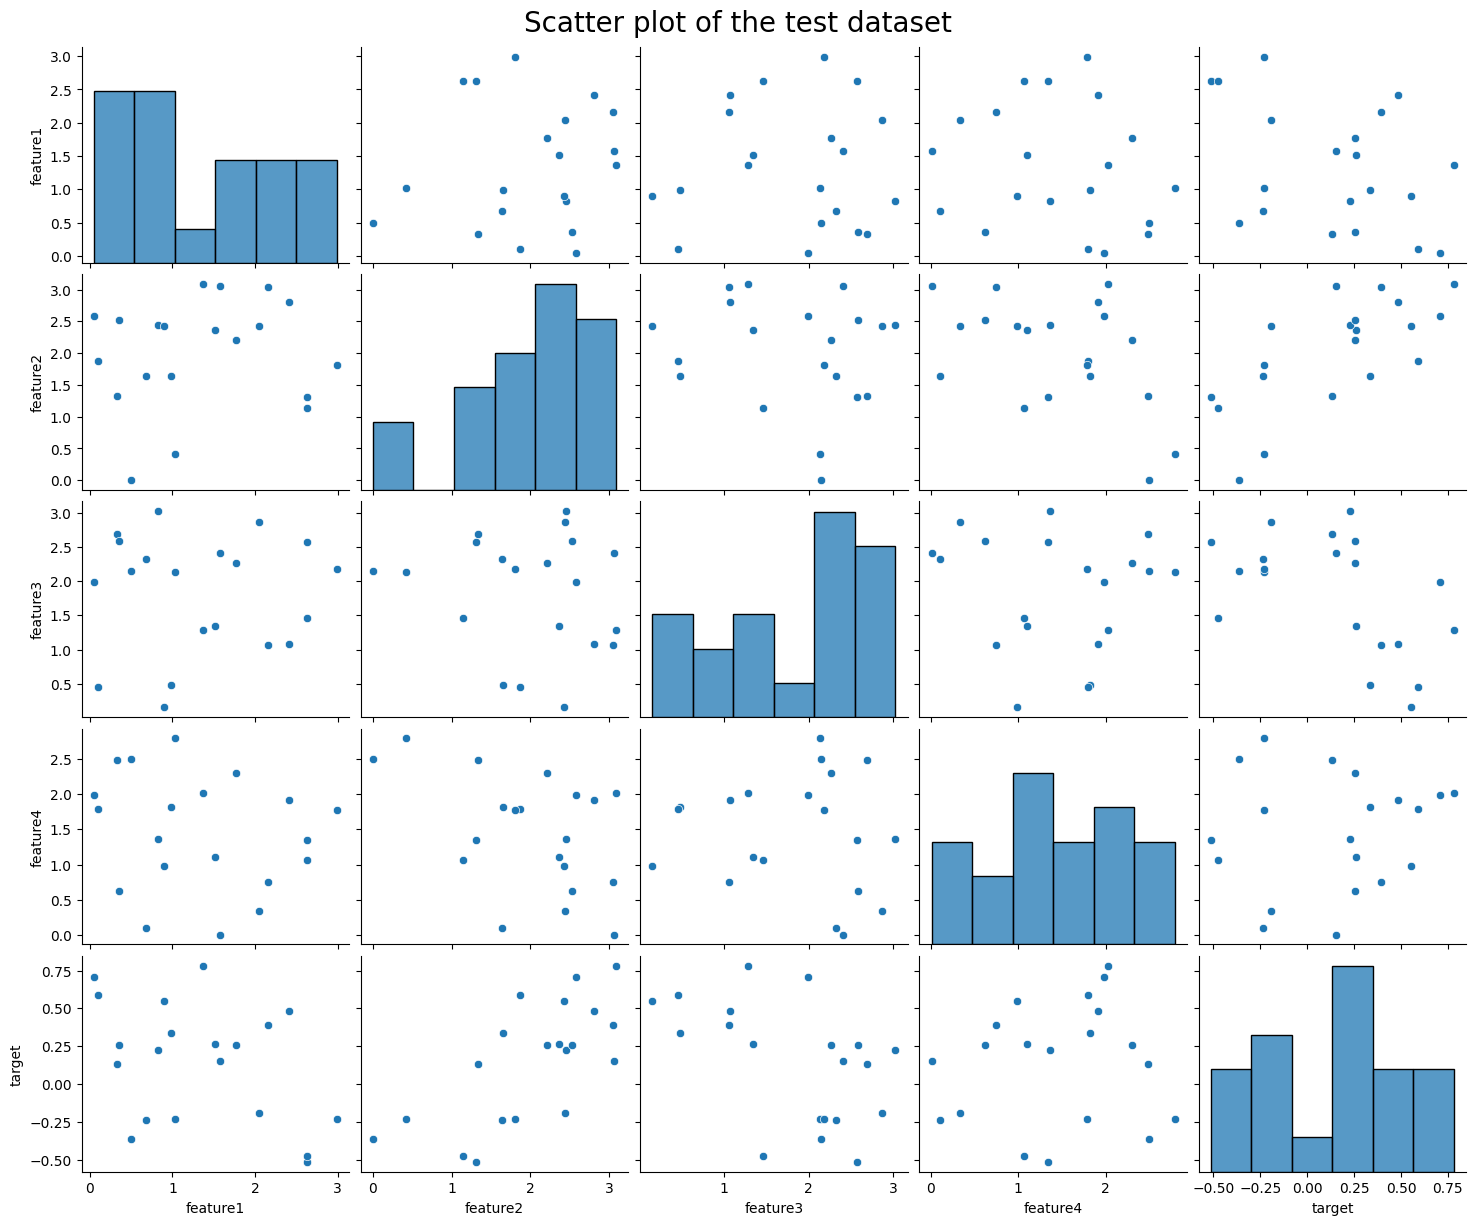

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the pairwise scatter plot
scatter_plot = sns.pairplot(data_train, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95) # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the training dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + 'scatter_plot_training_dataset.png')
plt.show()

scatter_plot_val = sns.pairplot(data_val, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95)  # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the validation dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + 'scatter_plot_validation_dataset.png')
plt.show()

scatter_plot_test = sns.pairplot(data_test, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95)  # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the test dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + 'scatter_plot_test_dataset.png')
plt.show()

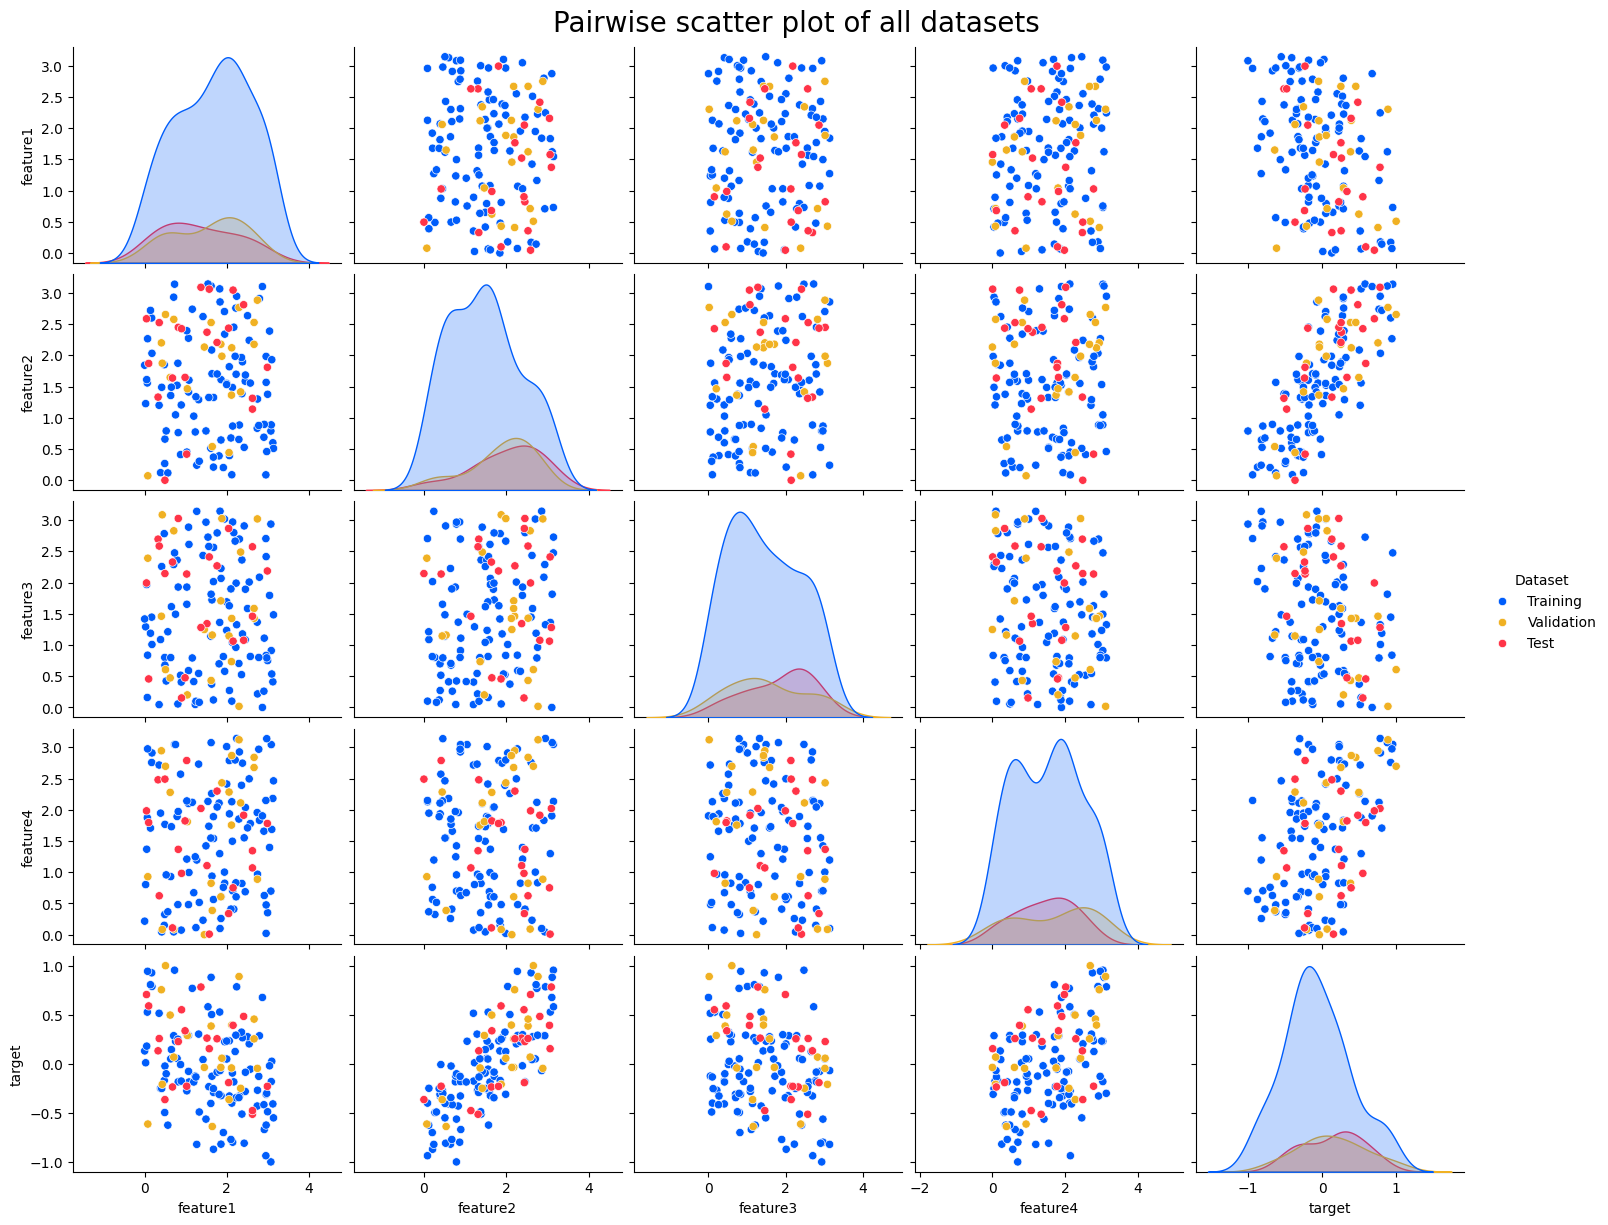

In [11]:
import pandas as pd

# Concatenate the dataframes
combined_data = pd.concat([data_train, data_val, data_test], ignore_index=True)

# Create a list with the dataset labels according to the number of datapoints
dataset_labels = (['Training'] * n_train) + (['Validation'] * n_val) + (['Test'] * n_test)

# Assign this list as a new column in the combined dataframe
combined_data['Dataset'] = dataset_labels

# Custom palette for color vision deficiencies
custom_palette = {'Training': '#005dfb',
                  'Validation': '#f0b123',
                  'Test': '#ff3448'}

# Plot using seaborn's pairplot with the 'hue' parameter
scatter_plot_combined = sns.pairplot(combined_data, hue='Dataset', height=2.5, aspect=1.2, palette=custom_palette)
plt.suptitle('Pairwise scatter plot of all datasets', fontsize=20)
plt.subplots_adjust(top=0.95)

# Save the plot
plt.savefig(dataset_EDA_dir + 'scatter_plot_combined_datasets.png')
plt.savefig(dataset_EDA_dir + 'scatter_plot_combined_datasets.pdf')
plt.show()

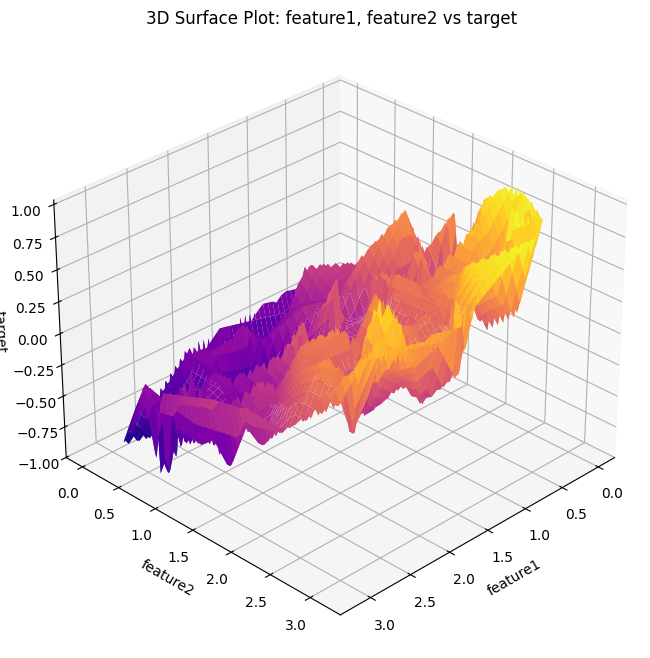

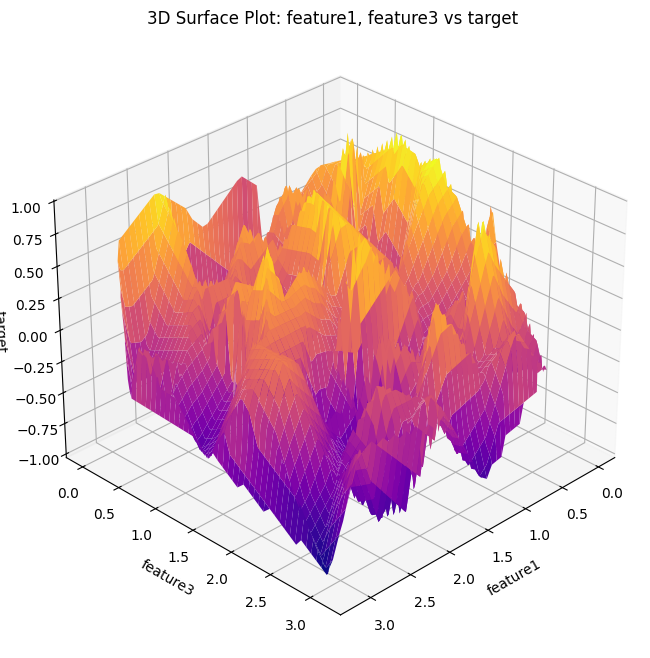

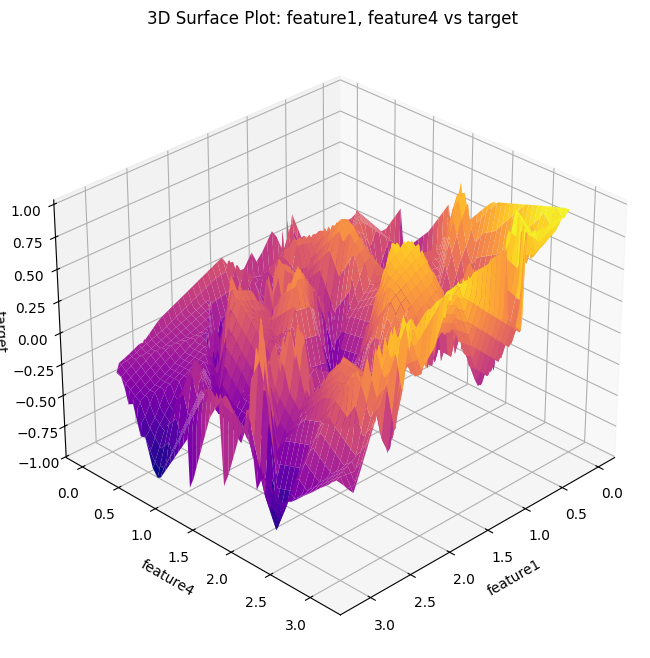

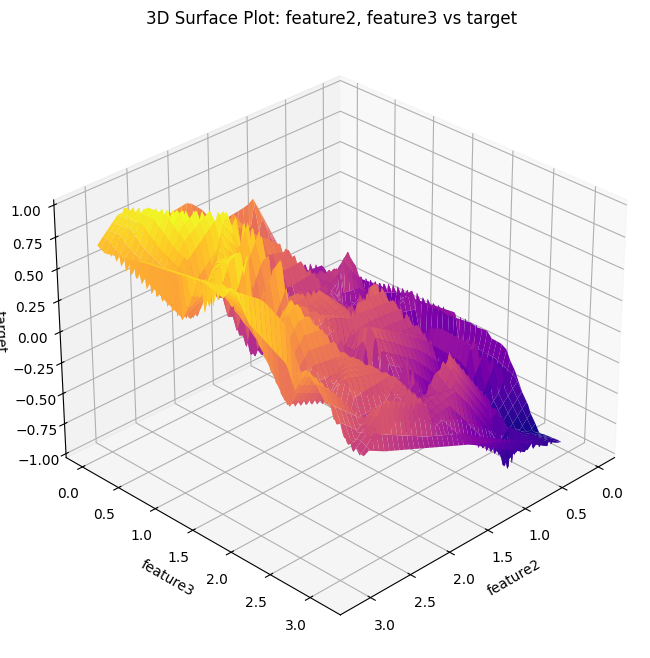

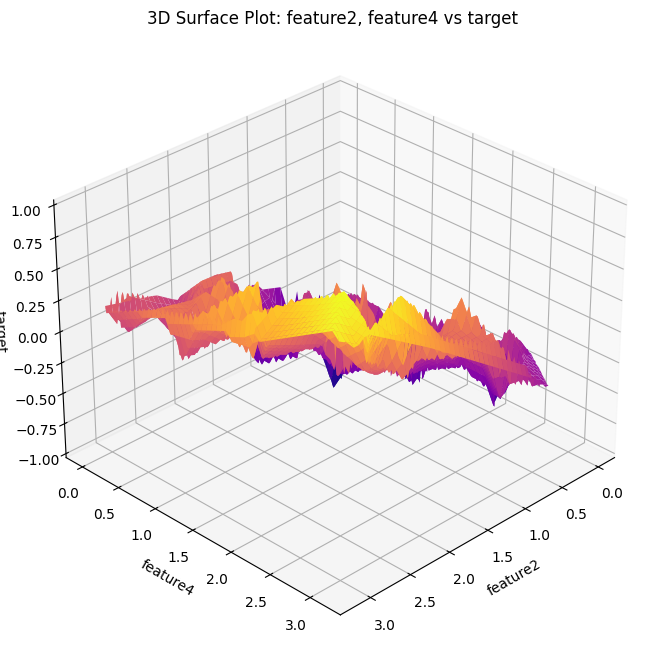

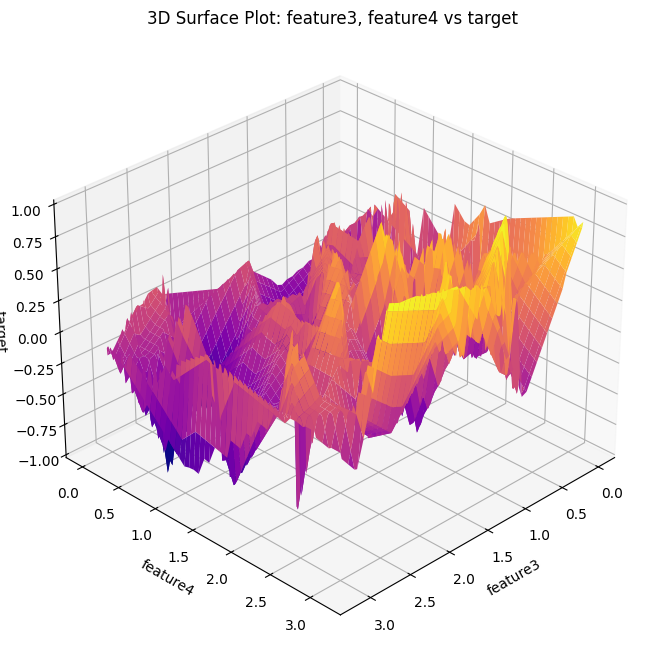

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations
from scipy.interpolate import griddata

# Assuming your dataset is stored in a DataFrame 'data'
# 'feature1', 'feature2', 'feature3', 'feature4' are the column names for your features
# 'target' is the column name for your target variable

# Extract the feature names and the target column
features = ['feature1', 'feature2', 'feature3', 'feature4']
target = 'target'

# Define a function to create a 3D surface plot for a given pair of features and the target
def plot_3d_surface(data, feature_x, feature_y, target, figsize=(10, 7), elev=30, azim=120):
    x = data[feature_x]
    y = data[feature_y]
    z = data[target]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 200)
    yi = np.linspace(y.min(), y.max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values on the grid
    zi = griddata((x, y), z, (xi, yi), method='linear') # 'linear', 'cubic', 'nearest'

    # Create the plot with specified size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    surf = ax.plot_surface(xi, yi, zi, cmap='plasma') # 'viridis', 'coolwarm', 'plasma'

    # Set the rotation angle
    ax.view_init(elev=elev, azim=azim)

    # Add labels and title
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target)
    ax.set_title(f'3D Surface Plot: {feature_x}, {feature_y} vs {target}')

    # Show the plot
    plt.show()

# Generate 3D surface plots for all combinations of pairs of features
# You can specify custom figsize, elevation, and azimuth values as needed
for feature_x, feature_y in combinations(features, 2):
    plot_3d_surface(data, feature_x, feature_y, target, figsize=(12, 8), elev=30, azim=45)


In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations
from scipy.interpolate import griddata

# Assuming your dataset is stored in a DataFrame 'data'
# 'feature1', 'feature2', 'feature3', 'feature4' are the column names for your features
# 'target' is the column name for your target variable

# Extract the feature names and the target column
features = ['feature1', 'feature2', 'feature3', 'feature4']
target = 'target'

def plot_3d_surface(ax, data, feature_x, feature_y, target, elev=30, azim=45):
    x = data[feature_x]
    y = data[feature_y]
    z = data[target]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values on the grid
    zi = griddata((x, y), z, (xi, yi), method='linear')

    # Plot the surface
    surf = ax.plot_surface(xi, yi, zi, cmap='plasma') # 'viridis', 'coolwarm', 'plasma'
    
    # Set the rotation angle
    ax.view_init(elev=elev, azim=azim)

    # Add labels
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target)
    ax.set_title(f'{feature_x}, {feature_y} vs {target}')

def create_3d_surface_grid(data, features, target, save_plot=False, filename=dataset_EDA_dir+'3d_surface_grid_dataset.png'):
    # Create a 2x3 grid of 3D surface plots
    fig = plt.figure(figsize=(20, 12))

    for i, (feature_x, feature_y) in enumerate(combinations(features, 2)):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        plot_3d_surface(ax, data, feature_x, feature_y, target)
        ax.view_init(elev=30, azim=45)

    plt.tight_layout()
    
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved as {filename}")
    
    plt.show()

Plot saved as dataset_wo_error/EDA_result/3d_surface_grid_dataset.png


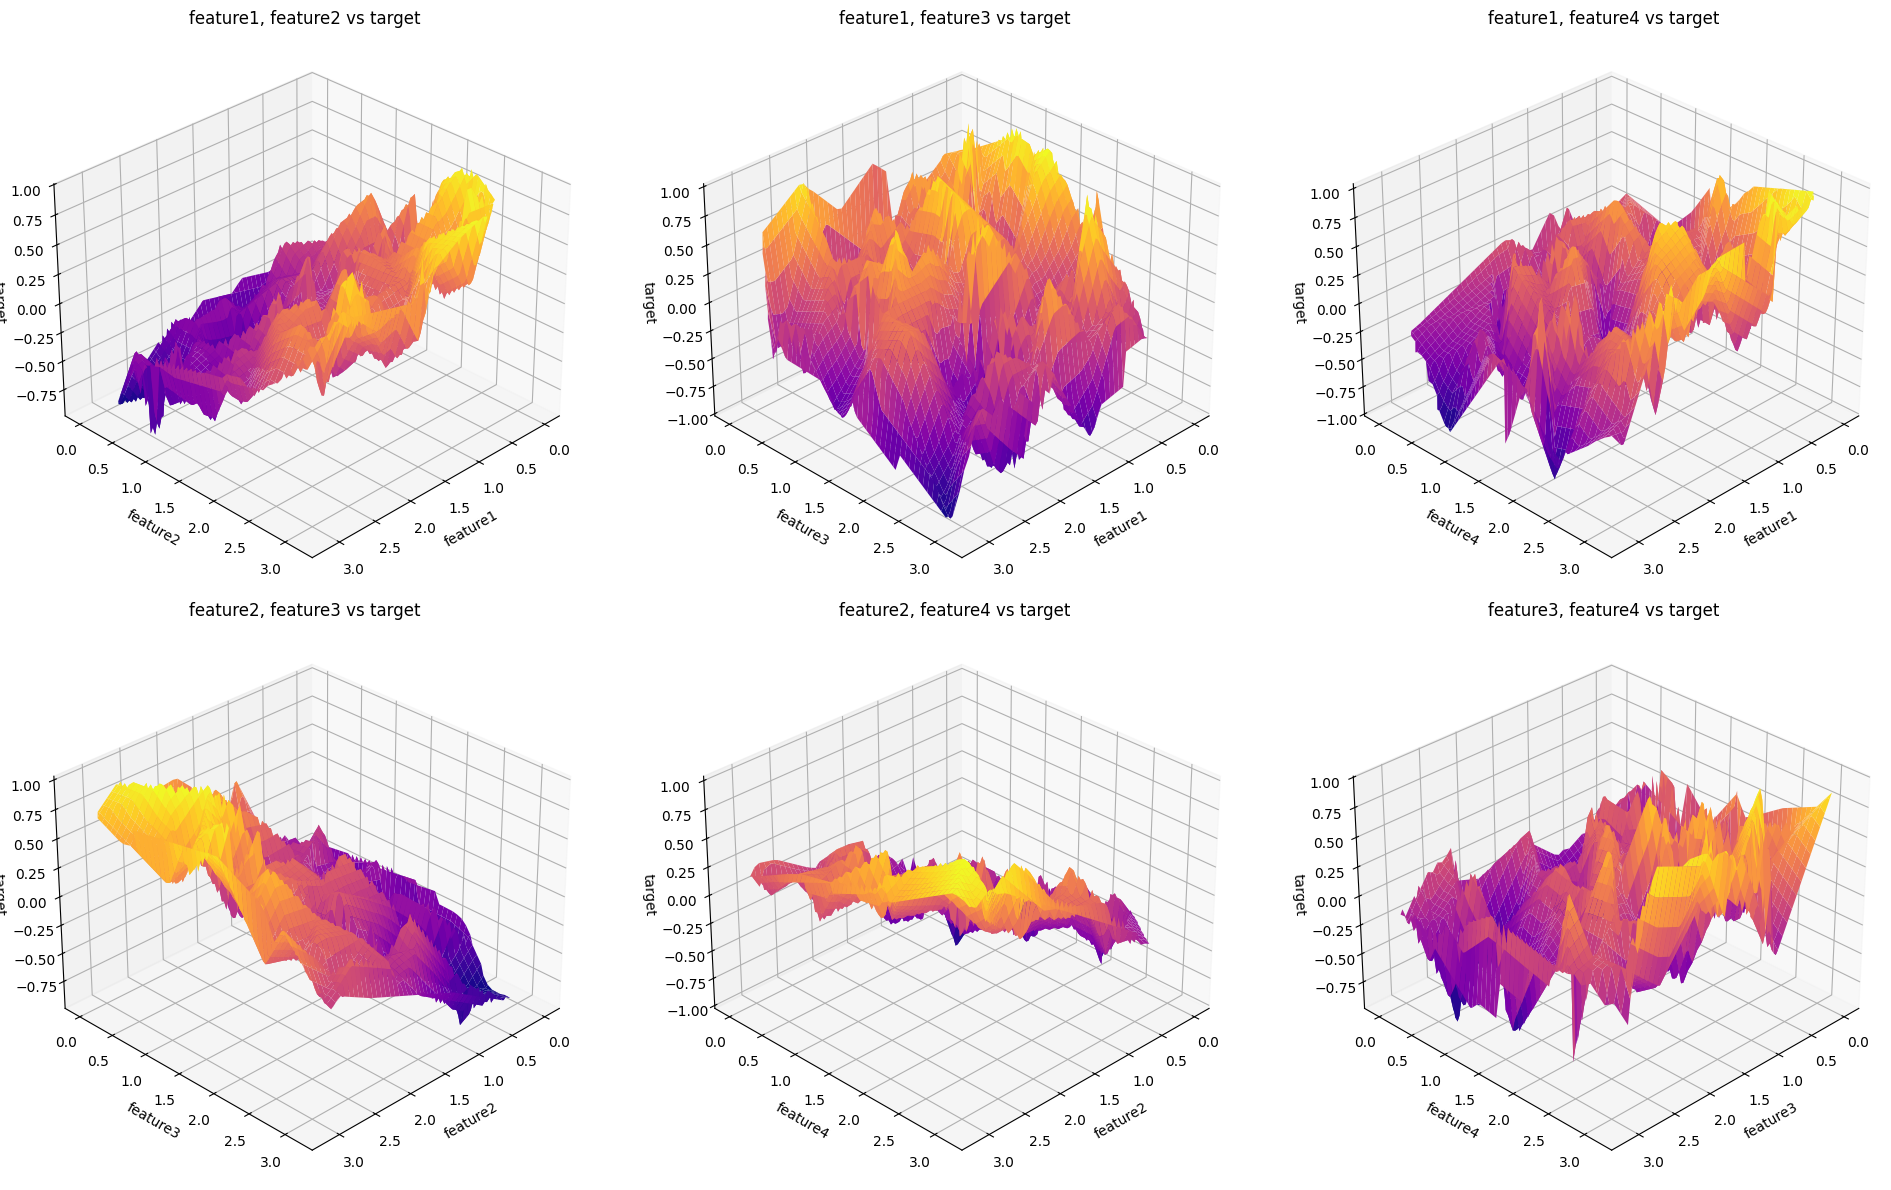

In [14]:
create_3d_surface_grid(data, features, target, save_plot=True)

## Descriptive statistics of the dataset

In [15]:
# Descriptive statistcs of each features of the DataFrame
data_train_stats = data_train.describe()
print(data_train_stats, '\n')

data_val_stats = data_val.describe()
print(data_val_stats, '\n')

data_test_stats = data_test.describe()
print(data_test_stats)

         feature1    feature2    feature3    feature4      target
count  100.000000  100.000000  100.000000  100.000000  100.000000
mean     1.680833    1.470182    1.441886    1.536813   -0.066778
std      0.914974    0.863149    0.919446    0.931068    0.452941
min      0.000000    0.086054    0.000000    0.020855   -1.000000
25%      0.887976    0.769855    0.702571    0.695172   -0.332311
50%      1.791065    1.486485    1.342915    1.671245   -0.113394
75%      2.374435    1.995888    2.233056    2.143199    0.232234
max      3.141593    3.141593    3.141593    3.141593    0.953940 

        feature1   feature2   feature3   feature4     target
count  20.000000  20.000000  20.000000  20.000000  20.000000
mean    1.564032   1.876382   1.522600   1.680857   0.140227
std     0.855251   0.793587   0.986518   1.090432   0.453775
min     0.077063   0.070965   0.017969   0.000000  -0.638987
25%     0.688367   1.451633   0.701437   0.769187  -0.087310
50%     1.753092   2.125859   1.426932

In [16]:
# Add a column to indicate the dataset
data_train_stats['Dataset'] = 'Training'
data_val_stats['Dataset'] = 'Validation'
data_test_stats['Dataset'] = 'Test'

# Concatenate the descriptive statistics into a single DataFrame
all_stats = pd.concat([data_train_stats, data_val_stats, data_test_stats], axis=0)

# Reset the index if you want to make it a column in the CSV for clarity
all_stats.reset_index(inplace=True)

# Save the concatenated DataFrame to CSV
all_stats.to_csv(dataset_dir + 'all_datasets_descriptive_stats.csv', index=False)

## Boxplot of the dataset

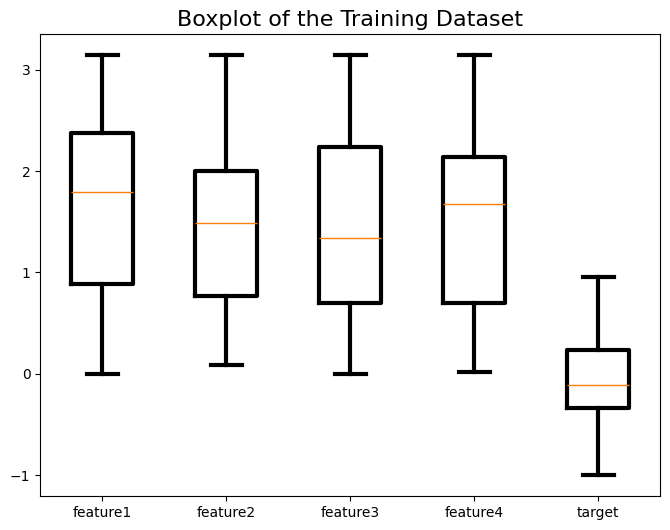

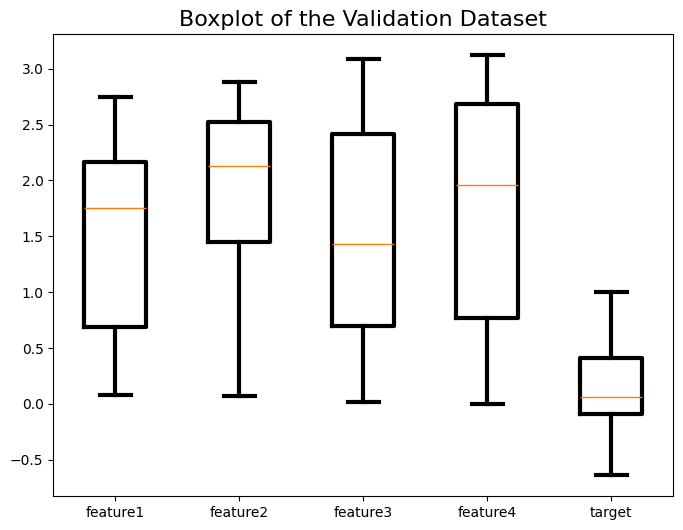

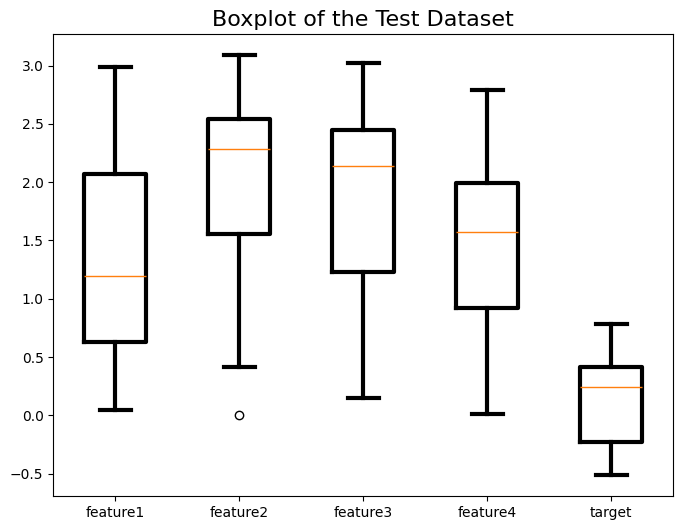

In [17]:
import matplotlib.pyplot as plt

# Common boxplot settings
boxprops = dict(linestyle='-', linewidth=3, color='k')
whiskerprops = dict(linestyle='-', linewidth=3, color='k')
capprops = dict(linestyle='-', linewidth=3, color='k')

# Plot for Training Dataset
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data_train, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Training Dataset', fontsize=16)
ax.set_xticklabels(data_train.columns, fontsize=10)
plt.savefig(dataset_EDA_dir + 'boxplot_training_dataset.png')
plt.show()

# Plot for Validation Dataset
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data_val, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Validation Dataset', fontsize=16)
ax.set_xticklabels(data_val.columns, fontsize=10)
plt.savefig(dataset_EDA_dir + 'boxplot_validation_dataset.png')
plt.show()

# Plot for Test Dataset
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data_test, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Test Dataset', fontsize=16)
ax.set_xticklabels(data_test.columns, fontsize=10)
plt.savefig(dataset_EDA_dir + 'boxplot_test_dataset.png')
plt.show()


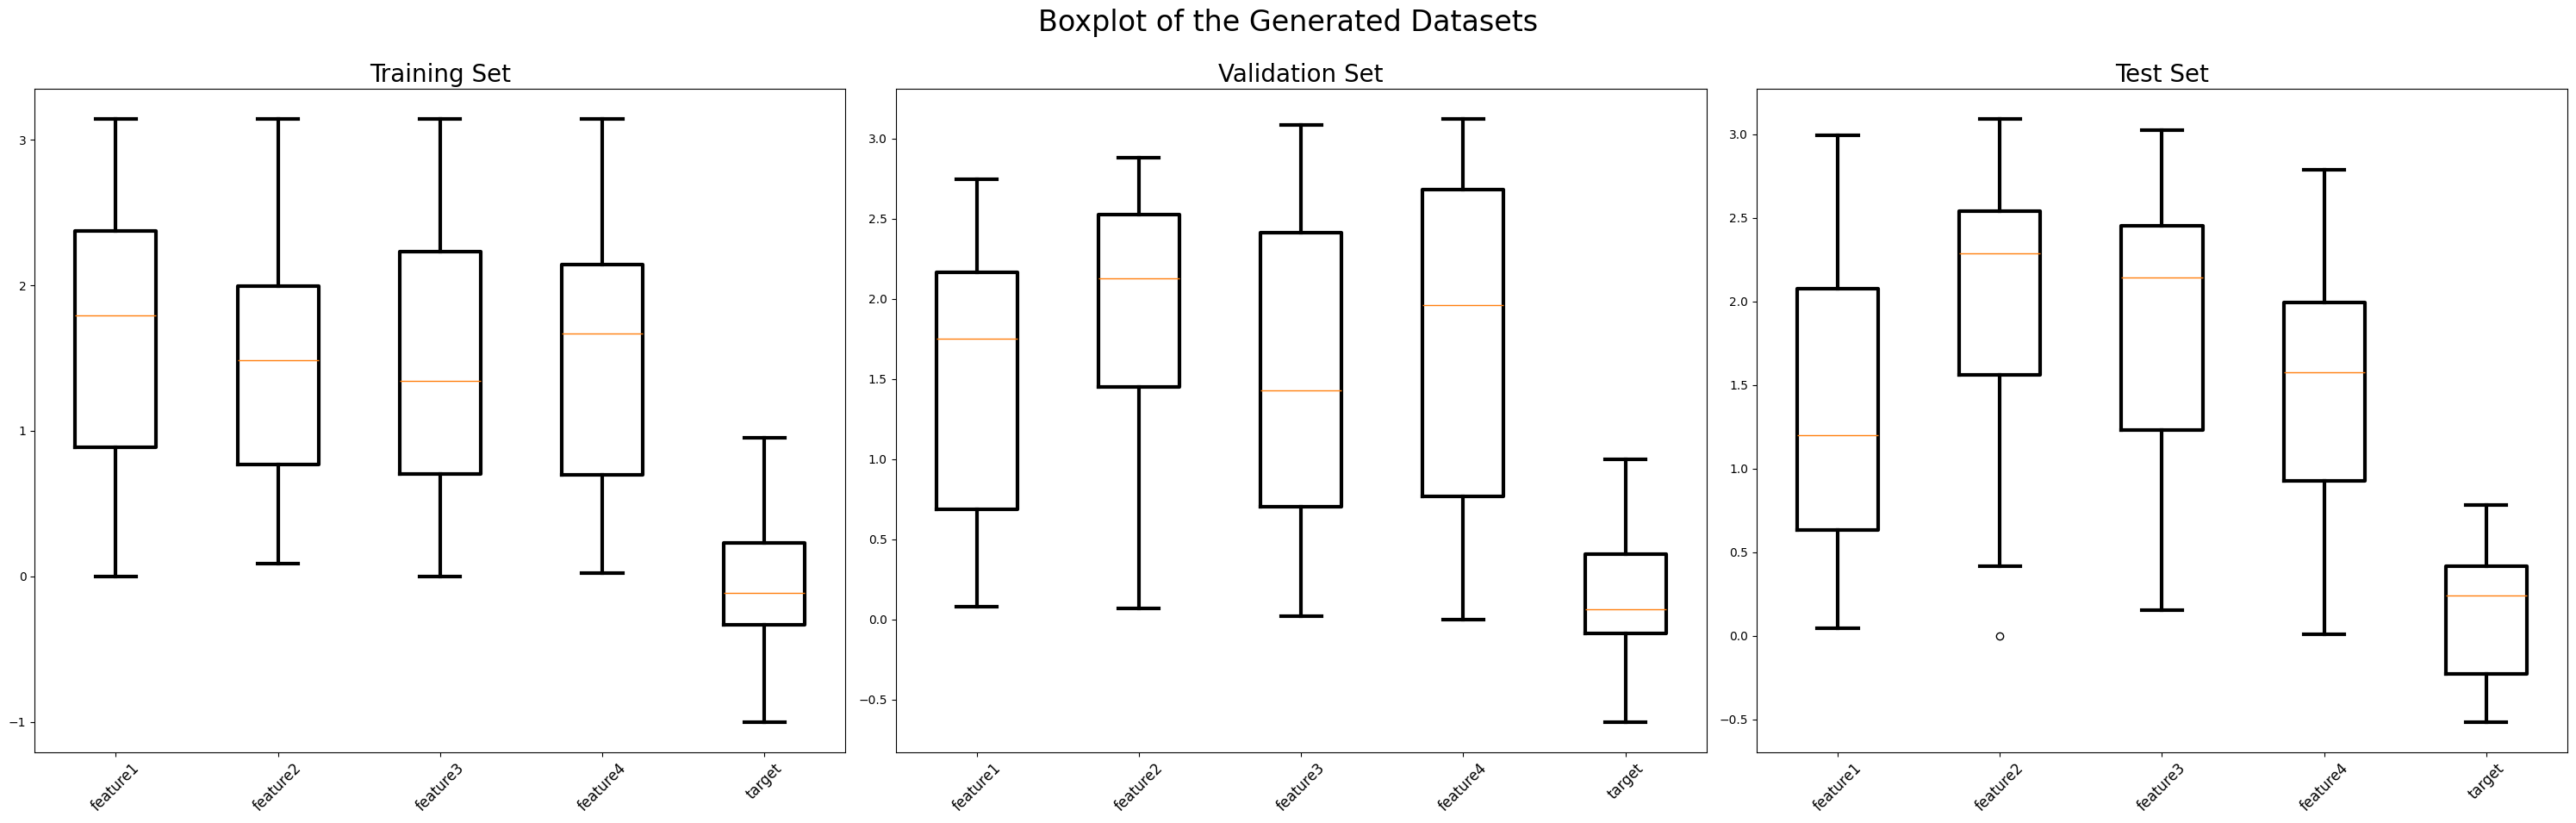

In [18]:
import matplotlib.pyplot as plt

# Define boxplot properties
boxprops = dict(linestyle='-', linewidth=3, color='k')
whiskerprops = dict(linestyle='-', linewidth=3, color='k')
capprops = dict(linestyle='-', linewidth=3, color='k')

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Adjust figsize to suit your needs

# Plot boxplot for each dataset
datasets = [data_train, data_val, data_test]
titles = ['Training Set', 'Validation Set', 'Test Set']

for ax, dataset, title in zip(axes, datasets, titles):
    ax.boxplot(dataset, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
    ax.set_title(title, fontsize=20)
    ax.set_xticklabels(dataset.columns, fontsize=12, rotation=45)  # Rotate labels for better legibility

fig.suptitle('Boxplot of the Generated Datasets', fontsize=24)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Adjust the rect parameters as needed for the title and labels
plt.savefig(dataset_EDA_dir + 'boxplot_combined_datasets.png')
plt.savefig(dataset_EDA_dir + 'boxplot_combined_datasets.pdf')
plt.show()


## Correlation plot of the dataset

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to create and save the heatmap
def create_heatmap(data, title, filename):
    correlation_matrix = data.corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_matrix,
                vmin=-1, vmax=1, annot=True, annot_kws={"size": 10},
                cmap="coolwarm", fmt=".4f", square=True)
    plt.title(title, fontsize=24)
    plt.tick_params(axis='x', labelsize=10)
    plt.tick_params(axis='y', labelsize=10)
    plt.savefig(filename)
    plt.show()

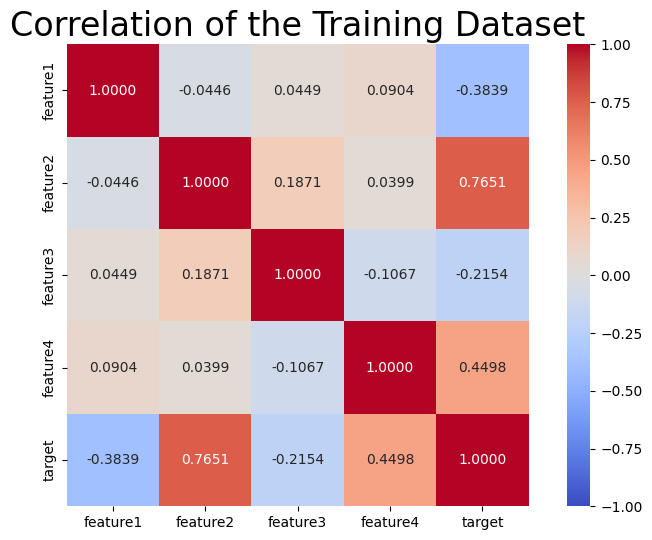

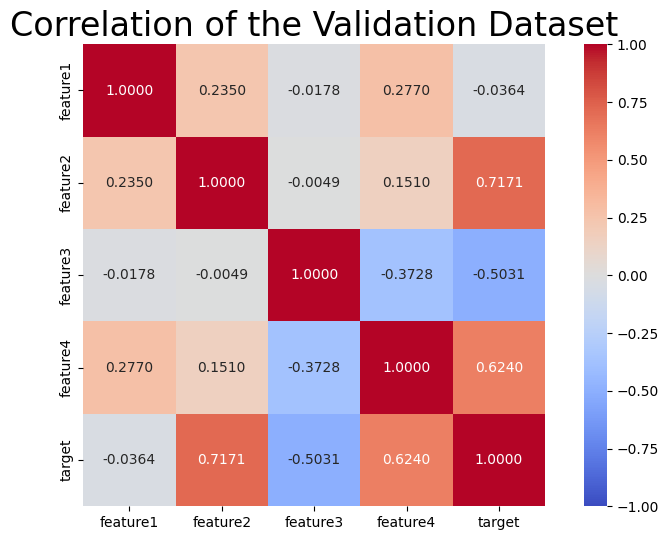

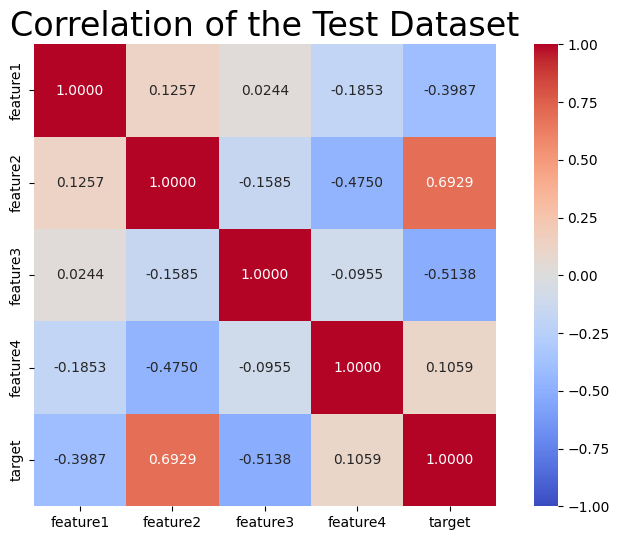

In [20]:
# Create and display the heatmap for the training, validation, and test dataset
create_heatmap(data_train,
               title = 'Correlation of the Training Dataset',
               filename = dataset_EDA_dir + 'corrplot_training_dataset.png')
create_heatmap(data_val, 
               title = 'Correlation of the Validation Dataset',
               filename = dataset_EDA_dir + 'corrplot_validation_dataset.png')
create_heatmap(data_test,
               title = 'Correlation of the Test Dataset',
               filename = dataset_EDA_dir + 'corrplot_test_dataset.png')

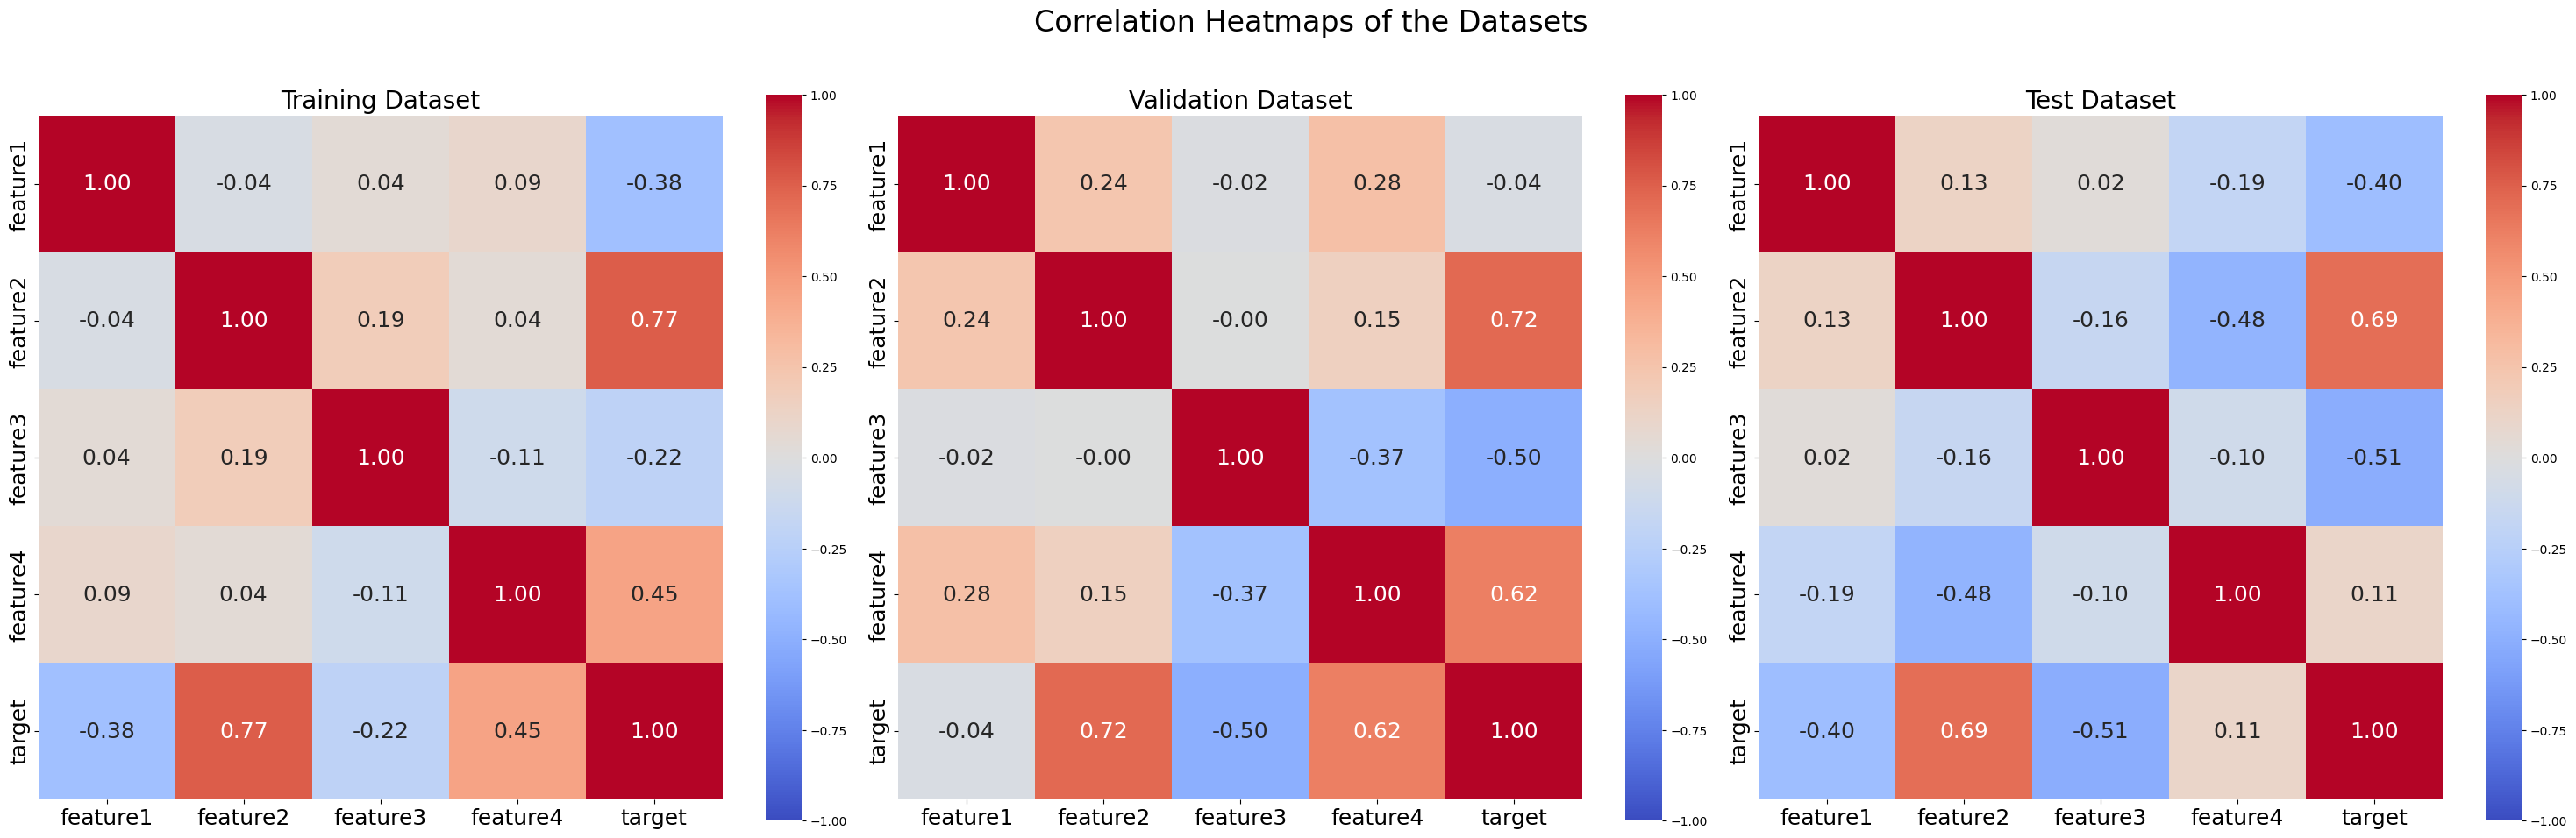

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Adjust the figsize to fit your needs

# List of datasets and their titles
datasets = [(data_train, 'Training Dataset'),
            (data_val, 'Validation Dataset'),
            (data_test, 'Test Dataset')]

for ax, (dataset, title) in zip(axes.flat, datasets):
    # Calculate the correlation matrix and create the heatmap
    correlation_matrix = dataset.corr()
    sns.heatmap(correlation_matrix, ax=ax,
                vmin=-1, vmax=1, annot=True, annot_kws={"size": 18},
                cmap="coolwarm", fmt=".2f", square=True)
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)

# Adjust layout for better visualization
plt.tight_layout()
plt.suptitle("Correlation Heatmaps of the Datasets", fontsize=24, y=0.98)  # Adjust 'y' for title spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the rect parameters as needed for the title and labels

# Save the entire figure with subplots
plt.savefig(dataset_EDA_dir + 'corrplot_combined_datasets.png')
plt.savefig(dataset_EDA_dir + 'corrplot_combined_datasets.pdf')
plt.show()


# Save / Load the dataset 

## Save the datasets into txt

In [22]:
# Store the column names in a list
column_names = data.columns.tolist()

In [23]:
def save_data(data, filename):
    data_array = data.to_numpy()
    np.savetxt(filename, data_array, delimiter='\t')

In [24]:
# Save each array to a text file without indices
save_data(data, dataset_dir + 'gen_data_reg.txt')
save_data(data_train, dataset_dir + 'data_train.txt')
save_data(data_val, dataset_dir + 'data_val.txt')
save_data(data_test, dataset_dir + 'data_test.txt')

## Load the datasets

In [25]:
## Load the generated dataset

data_train_load = np.loadtxt(dataset_dir + 'data_train.txt', delimiter='\t')
data_val_load = np.loadtxt(dataset_dir + 'data_val.txt', delimiter='\t')
data_test_load = np.loadtxt(dataset_dir + 'data_test.txt', delimiter='\t')

print('column_names:', column_names)

column_names: ['feature1', 'feature2', 'feature3', 'feature4', 'target']


In [26]:
# Create a new DataFrame with the column names
data_train_load = pd.DataFrame(data_train_load, columns=column_names)
data_val_load = pd.DataFrame(data_val_load, columns=column_names)
data_test_load = pd.DataFrame(data_test_load, columns=column_names)

In [27]:
data_train_load

,feature1,feature2,feature3,feature4,target
0,1.945559,2.700251,3.016153,1.001505,0.049972
1,2.451745,1.585118,1.083918,0.687405,-0.282062
2,2.310213,0.883766,2.696151,2.925777,-0.327975
3,2.751689,1.299747,0.216829,0.967941,-0.269473
4,2.548787,2.240201,2.007330,2.495329,0.203198
...,...,...,...,...,...
95,0.524773,0.789532,0.423506,0.957718,-0.101830
96,1.676098,0.369555,0.120023,1.889213,-0.252862
97,1.999529,1.531532,1.234416,3.010935,0.231663
98,2.782333,0.876521,0.800439,2.968903,-0.127999


In [28]:
data_val_load

,feature1,feature2,feature3,feature4,target
0,1.648232,0.538267,1.159531,0.387703,-0.638987
1,0.407682,2.199165,1.460285,2.944440,0.754728
2,2.116508,1.362406,0.733359,1.754279,-0.042242
3,1.620156,2.524578,0.431879,0.823365,0.384632
4,0.428718,1.873067,3.084273,0.083948,-0.209442
5,0.622149,1.645454,0.473055,2.278212,0.496554
6,1.857952,2.177287,1.707091,0.606654,-0.036472
7,0.710439,2.575488,2.827910,0.089850,0.068251
8,1.882480,1.985401,3.023797,2.430869,0.056879
9,2.340228,1.414144,2.487252,2.109697,-0.249899
